# Anchored Langevin on a heavy-tailed Gibbs target

Same experiments as `anchored_langevin_multivariate.ipynb`, with the potential replaced by

$$U(x)=\iota\log\bigl(1+\lVert x\rVert^2\bigr),\qquad \iota>1+\tfrac d2,
\qquad\Longrightarrow\qquad
\pi(x)\;\propto\;e^{-U(x)}=\bigl(1+\lVert x\rVert^2\bigr)^{-\iota}.$$

## What changed, and why it changes the point of the experiment

In every previous notebook $U$ was **non-differentiable** and the anchor's job was to route around the
kink. Here $U$ is $C^\infty$ — $\nabla U(x)=\dfrac{2\iota x}{1+\lVert x\rVert^2}$ is perfectly well defined
everywhere. The difficulty has moved to the **tail**: that gradient decays like $2\iota/\lVert x\rVert$, so
the restoring force *vanishes* far from the origin and a Langevin chain that wanders out drifts back only
very slowly. Heavy-tailed targets like this one are the standard example of subgeometric ergodicity for
Langevin dynamics.

So the anchor changes role — from smoothing a kink to **re-timing the tail** — and that is what the
experiments below measure.

## The target is a multivariate Student-$t$, so exact reference samples are available

Writing $\nu=2\iota-d$,

$$\pi(x)\propto\bigl(1+\lVert x\rVert^2\bigr)^{-(\nu+d)/2}$$

is the multivariate $t_\nu$ with scale matrix $\nu^{-1}I$. Hence the exact sampler

$$X=\frac{Z}{\sqrt{G}},\qquad Z\sim\mathcal N(0,I_d),\quad G\sim\chi^2_\nu,$$

with $\operatorname{Var}(X_i)=\dfrac1{\nu-2}$ whenever $\nu>2$. Note $\nu>2\iff\iota>1+\frac d2$: **the
condition in the problem statement is exactly the finite-variance condition**, which is also what makes
$W_1$ and the sampling floor well behaved. No rejection sampling needed anywhere.

## The anchor family

Take the anchor from the same family as the potential,

$$U_0^{(c)}(x)=c\log\bigl(1+\lVert x\rVert^2\bigr)
\qquad\Longrightarrow\qquad
\Delta=U-U_0=(\iota-c)\log\bigl(1+\lVert x\rVert^2\bigr),\quad
e^{\Delta}=\bigl(1+\lVert x\rVert^2\bigr)^{\iota-c},$$

so the anchored update has

$$\text{drift}=-2c\,x\bigl(1+\lVert x\rVert^2\bigr)^{\iota-c-1},
\qquad \text{diffusion coefficient}=\bigl(1+\lVert x\rVert^2\bigr)^{\iota-c}.$$

Three regimes, controlled by one number:

| $c$ | drift | diffusion | what it is |
|---|---|---|---|
| $c=\iota$ | $\nabla U$ | $1$ | $\Delta\equiv0$: **plain Langevin**, the baseline |
| $c=\iota-\tfrac12$ | $\sim x\lVert x\rVert^{-1}$ | $\sim\lVert x\rVert$ | partial tail acceleration |
| $c=\iota-1$ | $-2(\iota-1)x$ — **linear** | $\sim\lVert x\rVert^{2}$ | full re-timing: Gaussian-like restoring force |

At $c=\iota-1$ the vanishing restoring force is repaired exactly: the drift becomes linear in $x$, as if
the target were Gaussian, while the diffusion grows quadratically to keep $\pi$ invariant. That is the
heavy-tail analogue of what the pseudo-Huber anchor did for the kink — and it costs no extra oracle, since
$U$ still enters only through the scalar $e^{\Delta}$.

In [1]:
%matplotlib inline
import os
os.makedirs("figures", exist_ok=True)

import numpy as np
import torch
torch.set_default_dtype(torch.float64)
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import wasserstein_distance, kstest, ks_2samp

In [2]:
# -----------------------------
# Settings
# -----------------------------
d        = 3
IOTA     = 3.0            # must exceed 1 + d/2 = 2.5
NU       = 2 * IOTA - d   # Student-t degrees of freedom
N        = 5000
max_iter = 2000
eta      = 1e-3
x_start  = 0.5
SEED     = 1006
clamp_delta = 30.0        # never binds for these anchors; kept as a guard

print("d = {}, iota = {}  ->  nu = 2*iota - d = {}".format(d, IOTA, NU))
print("finite variance requires iota > 1 + d/2 = {}  ->  satisfied: {}".format(1 + d / 2, IOTA > 1 + d / 2))
print("theoretical coordinate std = 1/sqrt(nu-2) = {:.4f}".format(1 / np.sqrt(NU - 2)))

d = 3, iota = 3.0  ->  nu = 2*iota - d = 3.0
finite variance requires iota > 1 + d/2 = 2.5  ->  satisfied: True
theoretical coordinate std = 1/sqrt(nu-2) = 1.0000


In [3]:
# -----------------------------
# Exact target sampler: X = Z / sqrt(G), Z ~ N(0,I), G ~ chi2_nu
# (isotropic case; the anisotropic case below pushes it through L)
# -----------------------------
def sample_target(n, rng, iota=IOTA, dim=d, L=None):
    nu = 2 * iota - dim
    X = rng.normal(size=(n, dim)) / np.sqrt(rng.chisquare(nu, size=n))[:, None]
    return X if L is None else X @ L.T

# verification against the analytic radial density  p(r) ~ r^{d-1} (1+r^2)^{-iota}
rng = np.random.default_rng(SEED)
big = sample_target(200000, rng)
r = np.linalg.norm(big, axis=1)
grid = np.linspace(0, r.max(), 20001)
dens = grid ** (d - 1) * (1 + grid ** 2) ** (-IOTA)
cdf = np.cumsum(dens); cdf /= cdf[-1]
print("radial KS vs analytic density : {:.4f}".format(kstest(r, lambda t: np.interp(t, grid, cdf)).statistic))
print("coordinate std               : {:.4f}  (theory {:.4f})".format(big[:, 0].std(), 1 / np.sqrt(NU - 2)))
print("P(||x|| > 10)                : {:.5f}   -- tail decays like r^(-nu) = r^(-{})".format((r > 10).mean(), NU))

radial KS vs analytic density : 0.0040
coordinate std               : 1.0318  (theory 1.0000)
P(||x|| > 10)                : 0.00178   -- tail decays like r^(-nu) = r^(-3.0)


In [4]:
# -----------------------------
# Anchored Langevin, anchor U0 = c*log(1+|Mx|^2), constant skew J
# L = None  ->  isotropic target of the problem statement
# L given   ->  U = iota*log(1 + x' inv(Sigma) x), Sigma = L L'
# -----------------------------
def J_fun(dim, a):
    return torch.diag(a * torch.ones(dim - 1), diagonal=1) + torch.diag(-a * torch.ones(dim - 1), diagonal=-1)

def run(c, a=0.0, eta=eta, n_steps=max_iter, N=N, ref=None, L=None, iota=IOTA, dim=d,
        seed=SEED, track=True, quad_tau2=None):
    Mj = (torch.eye(dim) + J_fun(dim, a)).T
    Mi = None if L is None else torch.tensor(np.linalg.inv(L))
    torch.manual_seed(seed)
    x = torch.full((N, dim), x_start)

    W = []
    for _ in range(n_steps):
        y = x if Mi is None else x @ Mi.T
        s = torch.sum(y * y, dim=1, keepdim=True)
        if quad_tau2 is None:
            Delta = (iota - c) * torch.log1p(s).squeeze(1)
            g = 2 * c * y / (1 + s)                       # grad_y of c*log(1+|y|^2)
        else:
            Delta = (iota * torch.log1p(s) - 0.5 * s / quad_tau2).squeeze(1)
            g = y / quad_tau2                             # quadratic anchor
        if Mi is not None:
            g = g @ Mi                                    # chain rule back to x
        Delta = torch.clamp(Delta, -clamp_delta, clamp_delta)
        w = torch.exp(Delta).unsqueeze(1)
        x = x - eta * ((g * w) @ Mj) + np.sqrt(2 * eta) * torch.exp(0.5 * Delta).unsqueeze(1) * torch.randn_like(x)
        if track:
            xn = x.numpy()
            W.append([wasserstein_distance(ref[:, i], xn[:, i]) for i in range(dim)])
    return x.numpy(), (np.array(W) if track else None)

def w1_floor(ref, rng, L=None, reps=10):
    return [float(np.mean([wasserstein_distance(ref[:, i], sample_target(len(ref), rng, L=L)[:, i])
                           for _ in range(reps)])) for i in range(ref.shape[1])]

## Experiment 1 — the anchor exponent $c$ against the heavy tail

$J=0$ throughout this section, so the only thing varying is the anchor. The quadratic anchor
$U_0=\lVert x\rVert^2/(2\tau^2)$ is included as the natural "wrong family" comparison.

In [5]:
ref = sample_target(N, rng)
floor = w1_floor(ref, rng)
print("sampling floor:", np.round(floor, 4), "\n")

ANCHORS = {
    "c = iota  (plain Langevin)": dict(c=IOTA),
    "c = iota - 0.5":             dict(c=IOTA - 0.5),
    "c = iota - 1  (linear drift)": dict(c=IOTA - 1.0),
    "quadratic anchor, tau2 = 1": dict(c=IOTA, quad_tau2=1.0),
}
COL = {"c = iota  (plain Langevin)": "#4C72B0", "c = iota - 0.5": "#DD8452",
       "c = iota - 1  (linear drift)": "#55A868", "quadratic anchor, tau2 = 1": "#C44E52"}

exp1 = {}
q99_target = np.quantile(np.linalg.norm(sample_target(200000, rng), axis=1), 0.99)
print("{:<32}{:>26}{:>10}{:>12}".format("anchor", "W1 (dim1,dim2,dim3)", "std", "q99(||x||)"))
print("-" * 82)
for name, kw in ANCHORS.items():
    xf, W = run(a=0.0, ref=ref, **kw)
    exp1[name] = {"x": xf, "W1": W}
    print("{:<32}{:>26}{:>10.3f}{:>12.2f}".format(
        name, np.array2string(np.round(W[-100:].mean(axis=0), 4)), xf.std(),
        np.quantile(np.linalg.norm(xf, axis=1), 0.99)))
print("{:<32}{:>26}{:>10.3f}{:>12.2f}".format("target", np.array2string(np.round(floor, 4)), ref.std(), q99_target))

sampling floor: [0.0388 0.031  0.0325] 

anchor                                 W1 (dim1,dim2,dim3)       std  q99(||x||)
----------------------------------------------------------------------------------


c = iota  (plain Langevin)          [0.0799 0.078  0.0673]     0.779        3.63


c = iota - 0.5                      [0.0449 0.0363 0.0323]     0.881        4.56


c = iota - 1  (linear drift)        [0.0361 0.028  0.0306]     0.955        5.25


quadratic anchor, tau2 = 1          [0.0656 0.0458 0.042 ]     0.828        3.97
target                              [0.0388 0.031  0.0325]     1.094        5.40


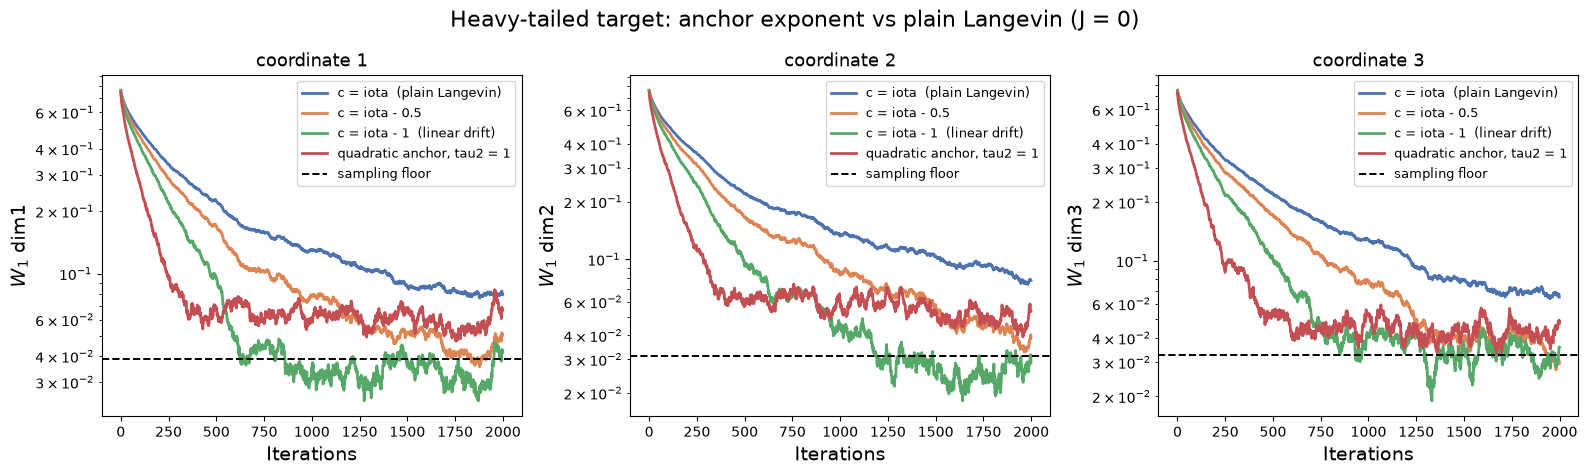

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
for i, ax in enumerate(axes):
    for name in ANCHORS:
        ax.plot(exp1[name]["W1"][:, i], linewidth=2, color=COL[name], label=name)
    ax.axhline(floor[i], color="k", linestyle="--", linewidth=1.4, label="sampling floor")
    ax.set_yscale("log")
    ax.set_xlabel("Iterations", fontsize=14)
    ax.set_ylabel("$W_1$ dim{}".format(i + 1), fontsize=14)
    ax.set_title("coordinate {}".format(i + 1), fontsize=13)
    ax.legend(fontsize=9)
fig.suptitle("Heavy-tailed target: anchor exponent vs plain Langevin (J = 0)", fontsize=16)
plt.tight_layout()
plt.savefig("figures/ht_w1_anchors.pdf", dpi=300, bbox_inches="tight")
plt.show()

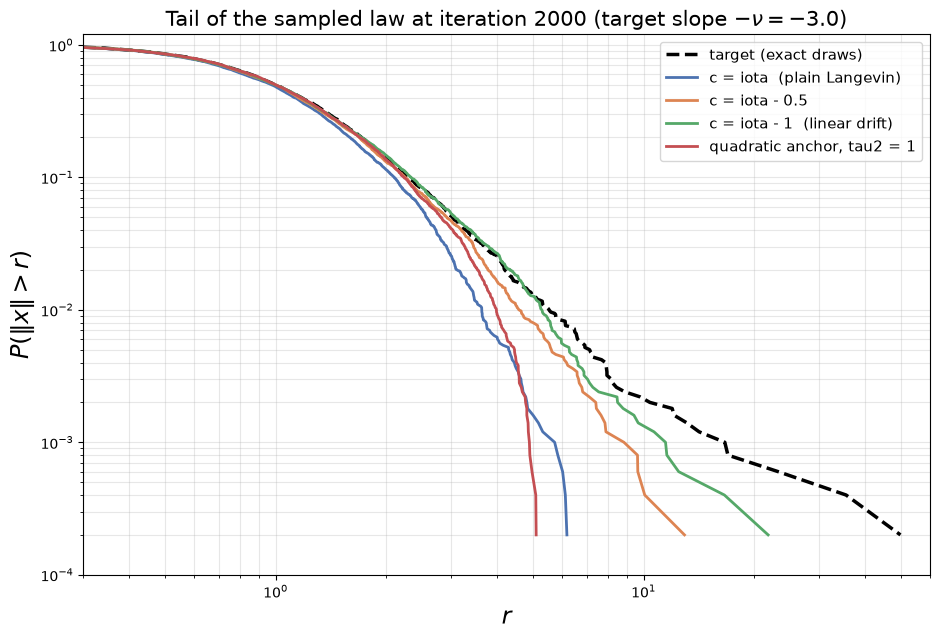

In [7]:
# The diagnostic that matters for a heavy tail: the survival function of ||x||, log-log.
# The target decays like r^(-nu), a straight line of slope -nu.
plt.figure(figsize=(9.5, 6.5))
def surv(v, ax=plt, **kw):
    s = np.sort(v)
    ax.plot(s, 1.0 - np.arange(len(s)) / len(s), **kw)

surv(np.linalg.norm(ref, axis=1), color="k", linewidth=2.5, linestyle="--", label="target (exact draws)")
for name in ANCHORS:
    surv(np.linalg.norm(exp1[name]["x"], axis=1), color=COL[name], linewidth=2, label=name)
plt.xscale("log"); plt.yscale("log")
plt.xlim(0.3, 60); plt.ylim(1e-4, 1.2)
plt.xlabel(r"$r$", fontsize=17)
plt.ylabel(r"$P(\|x\| > r)$", fontsize=17)
plt.title(r"Tail of the sampled law at iteration {} (target slope $-\nu = -{}$)".format(max_iter, NU), fontsize=15)
plt.grid(alpha=0.3, which="both")
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/ht_tail_survival.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 2 — $J_a$ vs $J=0$ on the target as stated

The potential in the problem statement depends on $x$ only through $\lVert x\rVert$, so the target is
**isotropic**. Non-reversible acceleration works by stirring slow directions against fast ones, and an
isotropic target has no such pairing — so the expectation is that $J$ does little here. Run it and see.

In [8]:
A_LIST = [0.0, 1.0, 2.0, 4.0]
iso = {}
print("{:<26}{:>26}".format("setting", "W1 (dim1, dim2, dim3)"))
print("-" * 54)
for c, tag in [(IOTA, "c = iota"), (IOTA - 1.0, "c = iota - 1")]:
    for a in A_LIST:
        xf, W = run(c=c, a=a, ref=ref)
        iso[(tag, a)] = W[-100:].mean(axis=0)
        print("{:<26}{:>26}".format("{}, a = {}".format(tag, a), np.array2string(np.round(iso[(tag, a)], 4))))

setting                        W1 (dim1, dim2, dim3)
------------------------------------------------------


c = iota, a = 0.0             [0.0799 0.078  0.0673]


c = iota, a = 1.0             [0.0857 0.07   0.0678]


c = iota, a = 2.0             [0.0773 0.0602 0.0637]


c = iota, a = 4.0             [0.0673 0.0528 0.061 ]


c = iota - 1, a = 0.0         [0.0361 0.028  0.0306]


c = iota - 1, a = 1.0         [0.0423 0.0346 0.0443]


c = iota - 1, a = 2.0         [0.0523 0.0368 0.0465]


c = iota - 1, a = 4.0         [0.0642 0.0682 0.0691]


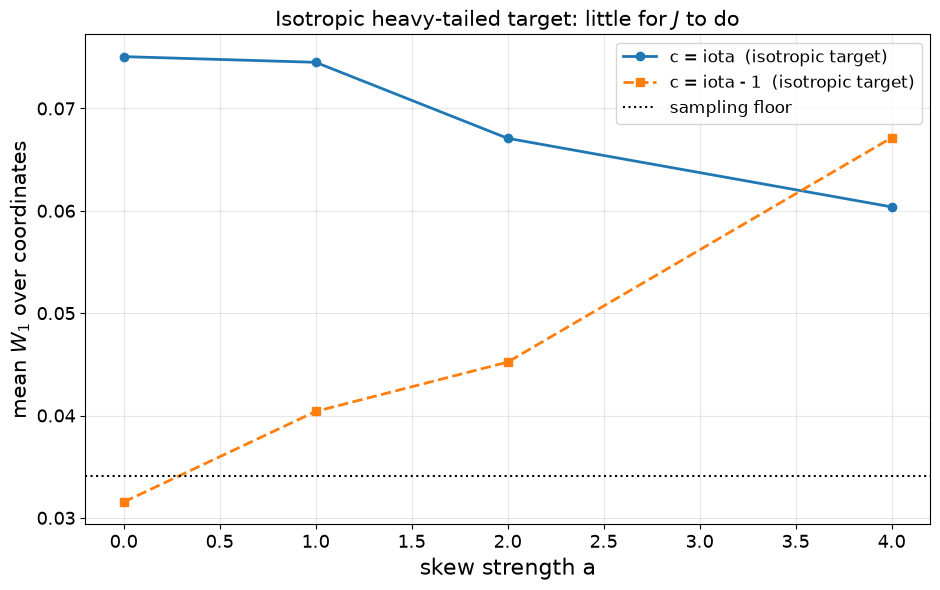

In [9]:
plt.figure(figsize=(9.5, 6))
for tag, style in [("c = iota", "-o"), ("c = iota - 1", "--s")]:
    plt.plot(A_LIST, [iso[(tag, a)].mean() for a in A_LIST], style, linewidth=2,
             label="{}  (isotropic target)".format(tag))
plt.axhline(np.mean(floor), color="k", linestyle=":", linewidth=1.5, label="sampling floor")
plt.xlabel("skew strength a", fontsize=16)
plt.ylabel("mean $W_1$ over coordinates", fontsize=15)
plt.title("Isotropic heavy-tailed target: little for $J$ to do", fontsize=15)
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("figures/ht_iso_J.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Experiment 3 — the anisotropic version, where $J$ has something to stir

Keep the same heavy-tailed family but give it a shape:

$$U(x)=\iota\log\bigl(1+x^\top\Sigma^{-1}x\bigr),\qquad \Sigma=DCD,\ D=\mathrm{diag}(0.5,1,2),\ \rho=0.6,$$

which is the multivariate $t_\nu$ with scale $\nu^{-1}\Sigma$, still exactly samplable as $L Z/\sqrt G$.
This is the heavy-tailed analogue of the correlated targets in the previous notebook, and it lets the two
mechanisms — anchor for the tail, $J$ for the anisotropy — be varied independently.

In [10]:
D = np.diag([0.5, 1.0, 2.0])
C = np.full((d, d), 0.6); np.fill_diagonal(C, 1.0)
L = np.linalg.cholesky(D @ C @ D)

ref_a = sample_target(N, rng, L=L)
floor_a = w1_floor(ref_a, rng, L=L)
print("anisotropic sampling floor:", np.round(floor_a, 4), "\n")

aniso = {}
print("{:<30}{:>26}".format("setting", "W1 (dim1, dim2, dim3)"))
print("-" * 58)
for c, tag in [(IOTA, "c = iota"), (IOTA - 1.0, "c = iota - 1")]:
    for a in [0.0, 1.0, 2.0, 4.0]:
        xf, W = run(c=c, a=a, ref=ref_a, L=L)
        aniso[(tag, a)] = {"W1": W, "x": xf}
        print("{:<30}{:>26}".format("{}, a = {}".format(tag, a),
                                    np.array2string(np.round(W[-100:].mean(axis=0), 4))))

anisotropic sampling floor: [0.0138 0.0301 0.0585] 

setting                            W1 (dim1, dim2, dim3)
----------------------------------------------------------


c = iota, a = 0.0                 [0.0558 0.1285 0.3701]


c = iota, a = 1.0                 [0.049  0.0923 0.3455]


c = iota, a = 2.0                 [0.0451 0.0774 0.3056]


c = iota, a = 4.0                 [0.0429 0.064  0.2847]


c = iota - 1, a = 0.0             [0.0171 0.0426 0.1217]


c = iota - 1, a = 1.0             [0.0162 0.0388 0.0946]


c = iota - 1, a = 2.0             [0.0192 0.0431 0.083 ]


c = iota - 1, a = 4.0             [0.0444 0.0882 0.1408]


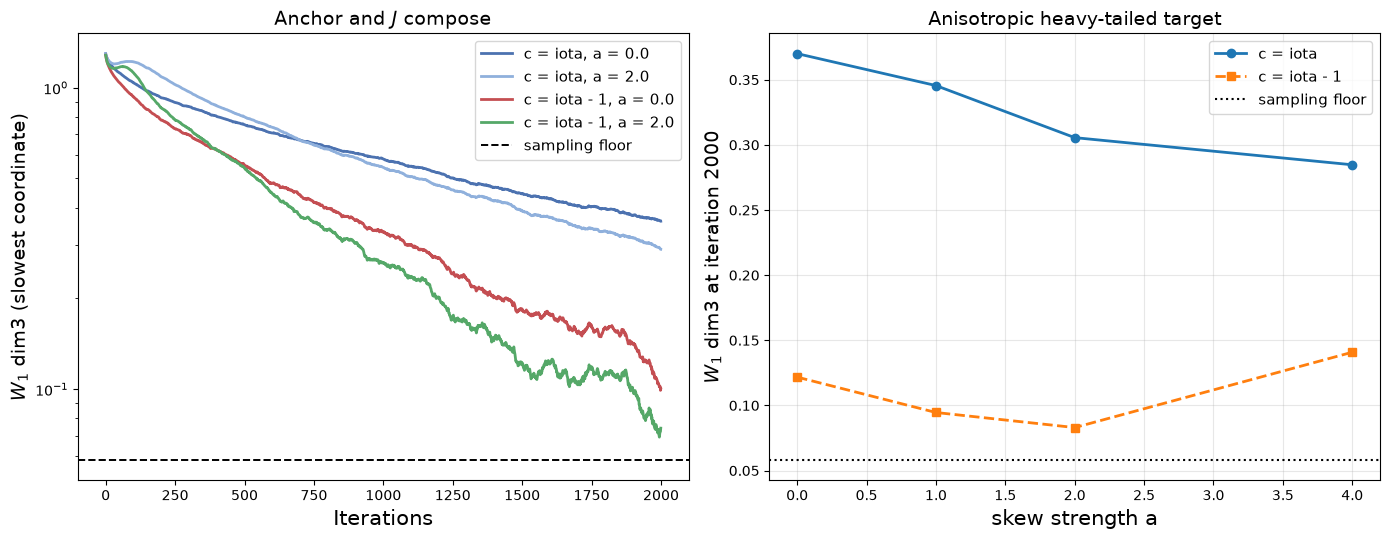

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
# left: W1 curves for the slowest coordinate, 2x2 grid of (anchor, J)
styles = {("c = iota", 0.0): ("#4C72B0", "-"), ("c = iota", 2.0): ("#8FB0DC", "-"),
          ("c = iota - 1", 0.0): ("#C44E52", "-"), ("c = iota - 1", 2.0): ("#55A868", "-")}
for (tag, a), (col, ls) in styles.items():
    axes[0].plot(aniso[(tag, a)]["W1"][:, 2], ls, color=col, linewidth=2,
                 label="{}, a = {}".format(tag, a))
axes[0].axhline(floor_a[2], color="k", linestyle="--", linewidth=1.4, label="sampling floor")
axes[0].set_yscale("log")
axes[0].set_xlabel("Iterations", fontsize=15)
axes[0].set_ylabel("$W_1$ dim3 (slowest coordinate)", fontsize=14)
axes[0].set_title("Anchor and $J$ compose", fontsize=14)
axes[0].legend(fontsize=11)

for tag, style in [("c = iota", "-o"), ("c = iota - 1", "--s")]:
    axes[1].plot([0.0, 1.0, 2.0, 4.0], [aniso[(tag, a)]["W1"][-100:, 2].mean() for a in [0.0, 1.0, 2.0, 4.0]],
                 style, linewidth=2, label=tag)
axes[1].axhline(floor_a[2], color="k", linestyle=":", linewidth=1.5, label="sampling floor")
axes[1].set_xlabel("skew strength a", fontsize=15)
axes[1].set_ylabel("$W_1$ dim3 at iteration {}".format(max_iter), fontsize=14)
axes[1].set_title("Anisotropic heavy-tailed target", fontsize=14)
axes[1].grid(alpha=0.3)
axes[1].legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/ht_aniso_J.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [12]:
# Invariance: neither the anchor exponent nor J may move the target.
print("{:<28}{:>12}{:>26}".format("setting", "KS dim3", "q99(||x||) vs target"))
print("-" * 68)
q99_t = np.quantile(np.linalg.norm(ref_a, axis=1), 0.99)
for (tag, a) in [("c = iota", 0.0), ("c = iota", 2.0), ("c = iota - 1", 0.0), ("c = iota - 1", 2.0)]:
    X = aniso[(tag, a)]["x"]
    print("{:<28}{:>12.4f}{:>26}".format("{}, a = {}".format(tag, a),
          ks_2samp(ref_a[:, 2], X[:, 2]).statistic,
          "{:.2f}  vs  {:.2f}".format(np.quantile(np.linalg.norm(X, axis=1), 0.99), q99_t)))

setting                          KS dim3      q99(||x||) vs target
--------------------------------------------------------------------
c = iota, a = 0.0                 0.0788            4.21  vs  7.15
c = iota, a = 2.0                 0.0600            4.70  vs  7.15
c = iota - 1, a = 0.0             0.0264            7.15  vs  7.15
c = iota - 1, a = 2.0             0.0156            7.97  vs  7.15


## Experiment 4 — fixed-physical-time control

As before: $(I+J)$ inflates the drift and the tail-accelerating anchor inflates it further, so hold
$T=\eta\cdot n_{\text{steps}}$ fixed and refine $\eta$. Whatever survives belongs to the dynamics.

In [13]:
print("W1 dim3 at fixed physical time T = 4, anisotropic target")
print("{:<12}{:<30}{:>12}".format("eta", "setting", "W1 dim3"))
print("-" * 56)
ctrl = {}
for eta_r, n_r in [(1e-3, 4000), (5e-4, 8000), (2.5e-4, 16000)]:
    for c, tag in [(IOTA, "c = iota"), (IOTA - 1.0, "c = iota - 1")]:
        for a in [0.0, 2.0]:
            xf, _ = run(c=c, a=a, eta=eta_r, n_steps=n_r, ref=ref_a, L=L, track=False)
            ctrl[(eta_r, tag, a)] = wasserstein_distance(ref_a[:, 2], xf[:, 2])
            print("{:<12}{:<30}{:>12.4f}".format(eta_r, "{}, a = {}".format(tag, a), ctrl[(eta_r, tag, a)]))

W1 dim3 at fixed physical time T = 4, anisotropic target
eta         setting                            W1 dim3
--------------------------------------------------------


0.001       c = iota, a = 0.0                   0.1939


0.001       c = iota, a = 2.0                   0.1254


0.001       c = iota - 1, a = 0.0               0.0655


0.001       c = iota - 1, a = 2.0               0.0827


...

0.0005      c = iota - 1, a = 2.0               0.0635


0.00025     c = iota, a = 0.0                   0.1968


0.00025     c = iota, a = 2.0                   0.1451


0.00025     c = iota - 1, a = 0.0               0.0364


0.00025     c = iota - 1, a = 2.0               0.0504


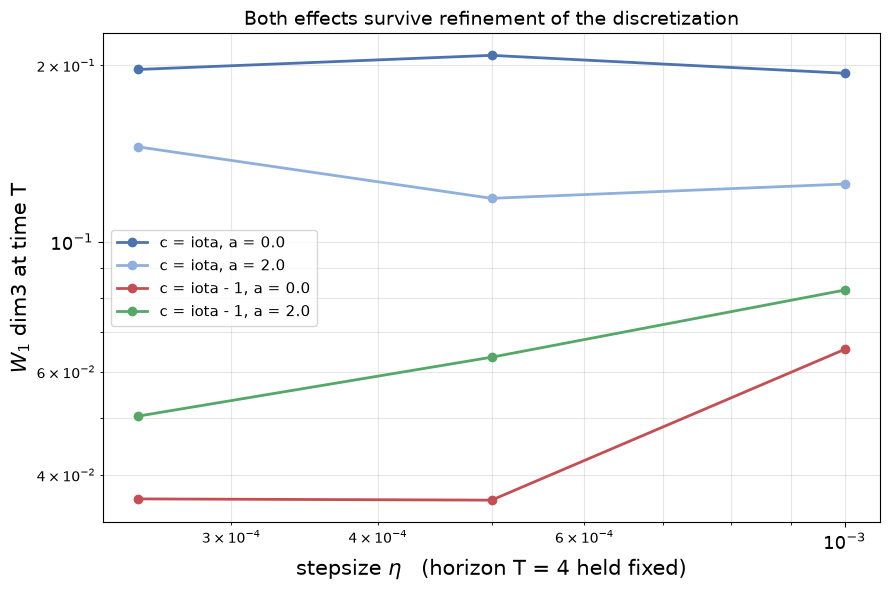

In [14]:
etas = [1e-3, 5e-4, 2.5e-4]
plt.figure(figsize=(9, 6))
for (tag, a), (col, ls) in styles.items():
    plt.plot(etas, [ctrl[(e, tag, a)] for e in etas], marker="o", linestyle=ls, color=col, linewidth=2,
             label="{}, a = {}".format(tag, a))
plt.xscale("log"); plt.yscale("log")
plt.xlabel(r"stepsize $\eta$   (horizon T = 4 held fixed)", fontsize=15)
plt.ylabel("$W_1$ dim3 at time T", fontsize=15)
plt.title("Both effects survive refinement of the discretization", fontsize=14)
plt.tick_params(labelsize=13)
plt.grid(alpha=0.3, which="both")
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("figures/ht_control.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Summary

**The difficulty moved from the kink to the tail, and so did the anchor's job.** $U=\iota\log(1+\lVert x\rVert^2)$
is smooth, so nothing here needs a subgradient; what breaks Langevin is that $\nabla U\sim 2\iota/\lVert x\rVert$
vanishes in the tail. Choosing the anchor from the same log family turns one exponent $c$ into a tail
control, and at $c=\iota-1$ the drift becomes exactly linear — the restoring force a Gaussian would have —
while the diffusion grows like $\lVert x\rVert^2$ to keep $\pi$ invariant.

**That single change is worth more than anything else in this notebook** (isotropic target, $J=0$,
iteration 2000; floor $=(0.039,0.031,0.033)$, target std $1.094$, target $q_{99}(\lVert x\rVert)=5.40$):

| anchor | $W_1$ | std | $q_{99}(\lVert x\rVert)$ |
|---|---|---|---|
| $c=\iota$ (plain Langevin) | $(0.080,0.078,0.067)$ | 0.779 | 3.63 |
| $c=\iota-\tfrac12$ | $(0.045,0.036,0.032)$ | 0.881 | 4.56 |
| **$c=\iota-1$ (linear drift)** | $(0.036,0.028,0.031)$ | **0.955** | **5.25** |
| quadratic, $\tau^2=1$ | $(0.066,0.046,0.042)$ | 0.828 | 3.97 |

$c=\iota-1$ is at the sampling floor on every coordinate while plain Langevin is still a factor of 2 away.
The survival plot is the sharper diagnostic: the target is a straight line of slope $-\nu=-3$ on log-log,
and the samplers peel off it in exactly the order of $c$ — plain Langevin and the quadratic anchor near
$r\approx4$, $c=\iota-\frac12$ near $r\approx10$, $c=\iota-1$ near $r\approx20$. None has filled the tail
completely by iteration 2000, which is the honest state of a $t_3$ target at this budget.

**On the target exactly as posed, $J$ has little to offer.** $U$ depends on $x$ only through $\lVert x\rVert$,
so the target is isotropic and there are no slow/fast directions to stir against each other. With plain
Langevin, $J$ gives a mild gain (mean $W_1$ $0.075\to0.060$ at $a=4$); with the tail-accelerated anchor it
*hurts* ($0.032\to0.067$), because the anchor has already removed the bottleneck and $J$ only adds
discretization error. This is a negative result and it is the expected one.

**Give the target a shape and $J$ becomes useful again.** With $U=\iota\log(1+x^\top\Sigma^{-1}x)$,
$\Sigma=DCD$, $D=\mathrm{diag}(0.5,1,2)$, $\rho=0.6$, on the slowest coordinate at iteration 2000:

| | $a=0$ | $a=1$ | $a=2$ | $a=4$ |
|---|---|---|---|---|
| $c=\iota$ | 0.370 | 0.346 | 0.306 | 0.285 |
| $c=\iota-1$ | 0.122 | 0.095 | **0.083** | 0.141 |

Best combination $(c=\iota-1,\,a=2)$ beats plain Langevin without $J$ by $4.5\times$ ($0.083$ vs $0.370$).
Invariance survives both knobs: at $c=\iota-1$ the tail quantile lands on the target
($q_{99}=7.15$ against $7.15$; plain Langevin reaches only $4.21$), and KS on the slowest coordinate is
$0.016$–$0.026$ against $0.060$–$0.079$ for the un-anchored runs.

**The control changes one of these conclusions, so state it precisely.** Holding $T=\eta n$ fixed at 4 and
refining $\eta$ by $4\times$:

| setting | $\eta=10^{-3}$ | $5\times10^{-4}$ | $2.5\times10^{-4}$ |
|---|---|---|---|
| $c=\iota$, $a=0$ | 0.194 | 0.208 | 0.197 |
| $c=\iota$, $a=2$ | 0.125 | 0.119 | 0.145 |
| $c=\iota-1$, $a=0$ | 0.066 | 0.036 | **0.036** |
| $c=\iota-1$, $a=2$ | 0.083 | 0.064 | 0.050 |

For plain Langevin the $J$ gain survives refinement — real acceleration. For the tail-accelerated anchor it
does **not**: by $T=4$ the $a=0$ chain has already caught up and overtaken, so the advantage seen at
iteration 2000 ($T=2$) is an early-transient effect plus a larger effective step, not a faster limiting
dynamics. The two mechanisms are therefore **partly redundant rather than additive**: use $J$ when the
anchor is not already removing the bottleneck, and be wary of stacking them at a fixed stepsize, where the
combined drift inflation costs accuracy.